<a href="https://colab.research.google.com/github/Revathi-Gangadaran/Coffee_Sales/blob/main/Users_Behaviour_and_Revenue_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Setup Environment***

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

***Upload & Load Excel File (Multiple Sheets)***

In [4]:
from google.colab import files

# Upload file
uploaded = files.upload()

# Load Excel file
file_name = list(uploaded.keys())[0]

# Read both sheets
events_df = pd.read_excel(file_name, sheet_name='user_events')
products_df = pd.read_excel(file_name, sheet_name='products')

# Preview
events_df.head(), products_df.head()

Saving user_events.xlsx to user_events (1).xlsx


(   event_id  user_id      event_type              event_date  product_id  \
 0      8490     5024       page_view 2025-12-30 04:58:24.517         205   
 1      2296     1713       page_view 2025-12-30 05:10:26.276         201   
 2      3896     2558       page_view 2025-12-30 05:11:09.002         404   
 3      2297     1713     add_to_cart 2025-12-30 05:13:26.276         201   
 4      2298     1713  checkout_start 2025-12-30 05:16:26.276         201   
 
    amount traffic_source  
 0     NaN         social  
 1     NaN        organic  
 2     NaN        organic  
 3     NaN        organic  
 4     NaN        organic  ,
    product_id       product series  sales_price
 0         101     GTX Basic    GTX          550
 1         102       GTX Pro    GTX         4821
 2         201    MG Special     MG           55
 3         205   MG Advanced     MG         3393
 4         305  GTX Plus Pro    GTX         5482)

***Initial Exploration***

In [5]:
# Events dataset
print("Events Info:")
events_df.info()

# Products dataset
print("\nProducts Info:")
products_df.info()

# Missing values
print("\nMissing Values (Events):")
print(events_df.isnull().sum())

print("\nMissing Values (Products):")
print(products_df.isnull().sum())

Events Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9381 entries, 0 to 9380
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   event_id        9381 non-null   int64         
 1   user_id         9381 non-null   int64         
 2   event_type      9381 non-null   object        
 3   event_date      9381 non-null   datetime64[ns]
 4   product_id      9381 non-null   int64         
 5   amount          826 non-null    float64       
 6   traffic_source  9381 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 513.2+ KB

Products Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   product_id   6 non-null      int64 
 1   product      6 non-null      object
 2   series       6 non-null      object
 3   sale

***Data Exploration***

In [6]:
# Convert date column
events_df['event_date'] = pd.to_datetime(events_df['event_date'])

# Fill missing values
events_df['amount'] = events_df['amount'].fillna(0)

# Remove duplicates
events_df = events_df.drop_duplicates()
products_df = products_df.drop_duplicates()

***Merge Datasets***

In [7]:
# Merge on product_id (adjust if needed)
df = pd.merge(events_df, products_df, on='product_id', how='left')

df.head()

,event_id,user_id,event_type,event_date,product_id,amount,traffic_source,product,series,sales_price
0,8490,5024,page_view,2025-12-30 04:58:24.517,205,0.0,social,MG Advanced,MG,3393
1,2296,1713,page_view,2025-12-30 05:10:26.276,201,0.0,organic,MG Special,MG,55
2,3896,2558,page_view,2025-12-30 05:11:09.002,404,0.0,organic,GTX Plus Basic,GTX,1096
3,2297,1713,add_to_cart,2025-12-30 05:13:26.276,201,0.0,organic,MG Special,MG,55
4,2298,1713,checkout_start,2025-12-30 05:16:26.276,201,0.0,organic,MG Special,MG,55


***Feature Engineering***

In [8]:
# Date features
df['year'] = df['event_date'].dt.year
df['month'] = df['event_date'].dt.month

# Revenue (only purchases)
df['revenue'] = np.where(df['event_type'] == 'purchase', df['amount'], 0)

# Sales count
df['sales'] = np.where(df['event_type'] == 'purchase', 1, 0)

#***Exploratory Data Analysis (EDA)***

***Event Type Distribution***

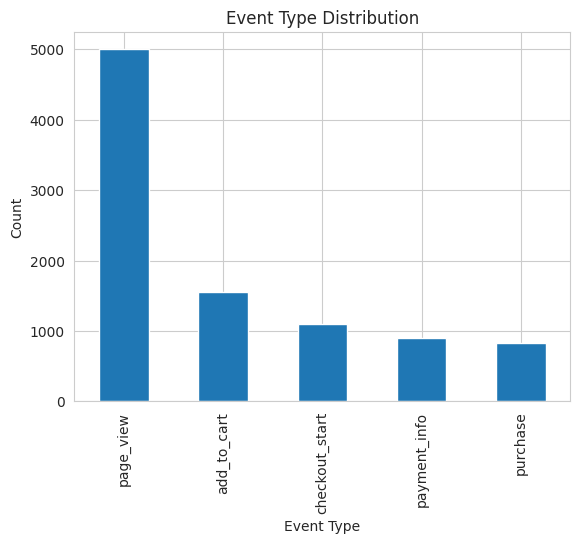

In [9]:
event_counts = df['event_type'].value_counts()

event_counts.plot(kind='bar')
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

***Traffic Source Analysis***

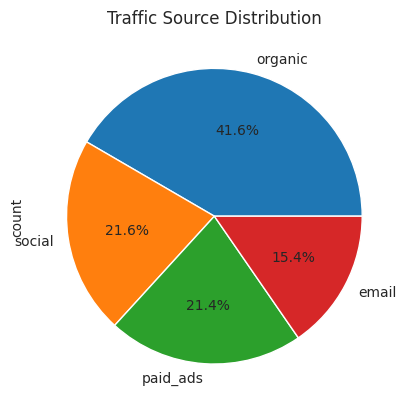

In [10]:
traffic_counts = df['traffic_source'].value_counts()

traffic_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Traffic Source Distribution")
plt.show()

***Revenue Over Time***

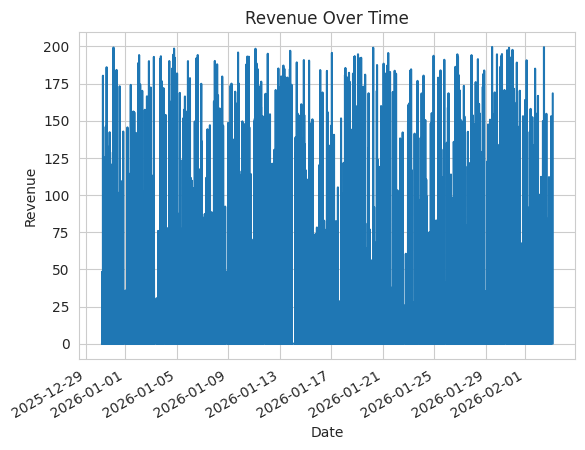

In [11]:
revenue_time = df.groupby('event_date')['revenue'].sum()

plt.figure()
revenue_time.plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

***Top Products by Revenue***

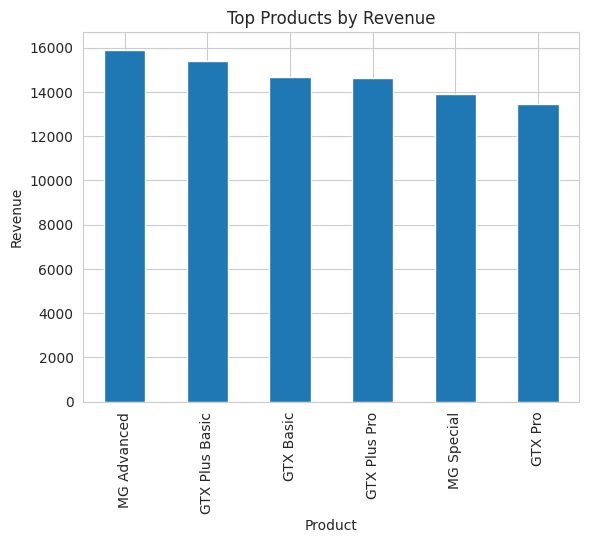

In [14]:
top_products = df.groupby('product')['revenue'].sum() \
                 .sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

***User Behaviour Analysis***

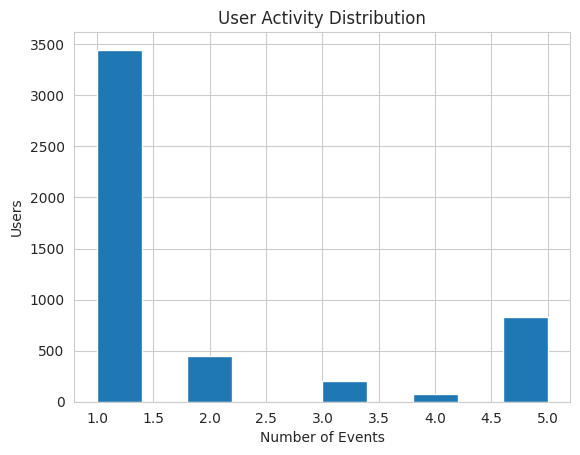

Average Revenue per User: 17.595022


In [19]:
# Events per user
user_activity = df.groupby('user_id')['event_id'].count()

user_activity.hist()
plt.title("User Activity Distribution")
plt.xlabel("Number of Events")
plt.ylabel("Users")
plt.show()

# Avg revenue per user
user_revenue = df.groupby('user_id')['revenue'].sum()

print("Average Revenue per User:", user_revenue.mean())

***Conversion Funnel***

Conversion Funnel:
event_type
page_view         5000
add_to_cart       1553
checkout_start    1103
payment_info       899
purchase           826
Name: count, dtype: int64


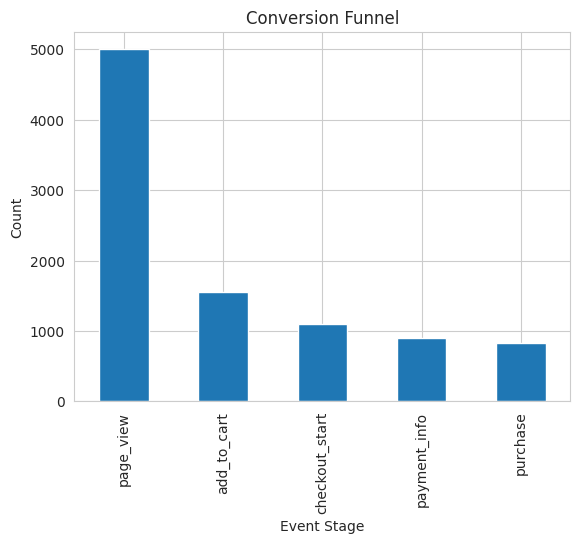

In [20]:
funnel = df['event_type'].value_counts()

print("Conversion Funnel:")
print(funnel)

# Optional visualization
funnel.plot(kind='bar')
plt.title("Conversion Funnel")
plt.xlabel("Event Stage")
plt.ylabel("Count")
plt.show()

***Key Metrics***

In [22]:
total_users = df['user_id'].nunique()
total_revenue = df['revenue'].sum()
total_sales = df['sales'].sum()
total_events = len(df)

print("Total Users:", total_users)
print("Total Revenue:", total_revenue)
print("Total Sales:", total_sales)
print("Total Events:", total_events)

Total Users: 5000
Total Revenue: 87975.11
Total Sales: 826
Total Events: 9381
